# stim1 category selectivity — by Costas cell type

Do putative **interneurons (inh)** and **pyramidal cells (exc)** — labelled by the **Costas**
classifier — encode stimulus category differently?

**Selectivity filter — one-vs-rest, max-statistic permutation (no double-dipping, no FDR):**
for each category *c*, `effect(c) = mean rate(c) − mean rate(all other categories)`. The observed
statistic is `S = max_c effect(c)`; the null **shuffles category labels and re-takes the max each
shuffle**, so choosing the best category is built into the null — this corrects for trying all 5
categories *and* removes the "pick the max then test it" bias. `selective = p < 0.05` per cell
(no FDR needed: the group comparison sits on a shared 5% false-positive floor).

Each cell also gets a **rate-invariant effect size** — the **AUC** of its selective category vs the
rest (0.5 = chance) — and we **rate-match** inh↔exc to check the comparison isn't just a
firing-rate power artifact (high-rate cells are easier to call selective).

Runs on **000673** (hippocampus+amygdala).

## Section 0 — Setup, config

In [1]:
# [0.1] imports, config
import sys, os, warnings, time, json
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd()                        # run this notebook from E:\SBCAT\celltyping
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from celltyping.selectivity import (load_spikes_trials, trial_onsets_categories,
                                    category_selectivity_ovr, psth,
                                    trial_table, epoch_alignment, window_counts)

RS = 42
plt.rcParams['figure.dpi'] = 100

# ---- CONFIG ----
DATASET   = '000673'
DATA_ROOT = PROJECT.parent / 'data' / DATASET
CELLTYPE_DIR = PROJECT / 'outputs' / 'celltype'      # where the unit_labels_* CSVs live
SELECT_AREAS = ['hippocampus', 'amygdala']           # MTL — where category cells live
CATS      = (1, 2, 3, 4, 5)                          # category = PicIDs_Encoding1 // 100
RESP_WIN  = (0.2, 1.0)      # encoding response window (s) after stim1 onset
PSTH_WIN  = (-0.5, 2.0); BIN_MS = 50.0; SIGMA_MS = 50.0    # encoding stimulus is ~2.0 s
ALPHA     = 0.05; MIN_TRIALS = 5
N_PERM    = 1000           # permutations for the one-vs-rest max-statistic test
BASELINE  = (-0.9, -0.3)   # baseline before pic1 onset; PSTH FRs shown as % change vs this
DELAY_STAT = (0.0, 2.5)    # delay window used for the load-1 delay statistics

# ---- CELL TYPE: Costas only ----
CELLTYPE_COL = 'costas_class'
GROUPS  = ['inh', 'exc']                              # [IN-analog, PY-analog]
GRP_COL = {'inh': '#d62728', 'exc': '#1f77b4'}        # inh red, exc blue
print(f'{DATASET} | region = {SELECT_AREAS} | cell type = {CELLTYPE_COL} {GROUPS} | '
      f'one-vs-rest max-stat, {N_PERM} perms, alpha={ALPHA}')

000673 | region = ['hippocampus', 'amygdala'] | cell type = costas_class ['inh', 'exc'] | one-vs-rest max-stat, 1000 perms, alpha=0.05


In [2]:
# [0.2] all session files
files = sorted(DATA_ROOT.glob('sub-*/*.nwb'))
assert files, f'no NWB files under {DATA_ROOT}'
print(f'{len(files)} session files under {DATA_ROOT}')

44 session files under E:\SBCAT\data\000673


## Section 1 — Load spikes + trials, join the Costas label

In [3]:
# [1.1] load spike times + per-session trials (no waveform recompute)
t0 = time.time()
units_df, spikes, trials_by_session = load_spikes_trials(files, areas=SELECT_AREAS, verbose=True)
print(f'\n{len(units_df)} units, {len(trials_by_session)} sessions in {time.time()-t0:.0f}s')
print('regions:', units_df.location.value_counts().to_dict())

  sub-1_ses-1_ecephys+image: 22 units, 140 trials


  sub-1_ses-2_ecephys+image: 26 units, 140 trials


  sub-10_ses-1_ecephys+image: 23 units, 140 trials


  sub-11_ses-1_ecephys+image: 15 units, 139 trials


  sub-12_ses-1_ecephys+image: 15 units, 140 trials


...

  sub-5_ses-2_ecephys+image: 10 units, 140 trials


  sub-6_ses-1_ecephys+image: 12 units, 140 trials


  sub-7_ses-1_ecephys+image: 17 units, 140 trials


  sub-8_ses-1_ecephys+image: 23 units, 140 trials


  sub-9_ses-1_ecephys+image: 12 units, 140 trials

856 units, 44 sessions in 24s
regions: {'amygdala_right': 263, 'amygdala_left': 233, 'hippocampus_left': 203, 'hippocampus_right': 157}


In [4]:
# [1.2] load the Costas cell-type label from unit_labels_costas_*.csv, join on unit_id
def load_label(col):
    frames = []
    for f in sorted(CELLTYPE_DIR.glob('unit_labels_*.csv')):
        d = pd.read_csv(f)
        if 'unit_id' in d.columns and col in d.columns:
            frames.append(d[['unit_id', col]])
    assert frames, f'no unit_labels_*.csv has a {col} column in {CELLTYPE_DIR}'
    return pd.concat(frames, ignore_index=True).dropna(subset=[col]).drop_duplicates('unit_id')

lab = load_label(CELLTYPE_COL).rename(columns={CELLTYPE_COL: 'celltype'})
units_df = units_df.merge(lab, on='unit_id', how='left').reset_index(drop=True)   # aligned to `spikes`
cov = units_df.celltype.notna().sum()
print(f'Costas label coverage: {cov}/{len(units_df)} ({cov/len(units_df):.0%})')
print(units_df.celltype.value_counts().to_string())

Costas label coverage: 856/856 (100%)
celltype
exc    581
inh    275


## Section 2 — Category-selective cells (one-vs-rest, max-statistic)

Per cell: `effect(c) = mean rate(c) − mean rate(rest)` for every category; `S = max_c effect(c)`;
null = shuffle category labels and re-take the max. `selective = p < ALPHA`. The cell's
**selective category** is `argmax_c effect(c)` — used downstream for the preferred-in/out PSTHs.

In [5]:
# [2.1] one-vs-rest max-statistic selectivity per unit
recs = []
for j, row in units_df.iterrows():
    if pd.isna(row.celltype):
        continue
    on, cat = trial_onsets_categories(trials_by_session.get(row.session_id), keep=CATS)
    sel = category_selectivity_ovr(spikes[j], on, cat, win=RESP_WIN, min_trials=MIN_TRIALS,
                                   n_perm=N_PERM, alpha=ALPHA, seed=RS)
    recs.append(dict(unit_id=row.unit_id, session_id=row.session_id, subject=row.subject,
                     location=row.location, celltype=row.celltype, p=sel['p'],
                     selective=sel['selective'], pref_cat=sel['pref_cat'],
                     best_effect=sel['best_effect'], best_auc=sel['best_auc'],
                     resp_rate=sel['resp_rate'], n_cat=sel['n_cat'], tested=sel['tested']))
sel_df = pd.DataFrame(recs)
n_tested = int(sel_df.tested.sum())
print(f'{n_tested} units tested | {int(sel_df.selective.sum())} category-selective '
      f'(one-vs-rest max-stat, p<{ALPHA})  = {sel_df.selective.mean():.0%} '
      f'(chance would be {ALPHA:.0%})')
sel_df.sort_values('p').head(12)

856 units tested | 155 category-selective (one-vs-rest max-stat, p<0.05)  = 18% (chance would be 5%)


,unit_id,session_id,subject,location,celltype,p,selective,pref_cat,best_effect,best_auc,resp_rate,n_cat,tested
855,sub-9_ses-1_ecephys+image_u012,sub-9_ses-1_ecephys+image,sub-9,amygdala_right,exc,0.000999,True,4,3.426339,0.805644,1.991071,5,True
851,sub-9_ses-1_ecephys+image_u008,sub-9_ses-1_ecephys+image,sub-9,amygdala_right,exc,0.000999,True,2,3.091518,0.709662,4.133929,5,True
119,sub-15_ses-1_ecephys+image_u015,sub-15_ses-1_ecephys+image,sub-15,amygdala_right,exc,0.000999,True,2,5.982143,0.796716,7.982143,5,True
128,sub-15_ses-1_ecephys+image_u024,sub-15_ses-1_ecephys+image,sub-15,amygdala_right,exc,0.000999,True,2,5.223214,0.749043,8.008929,5,True
765,sub-4_ses-1_ecephys+image_u040,sub-4_ses-1_ecephys+image,sub-4,hippocampus_right,exc,0.000999,True,5,6.550311,0.784005,10.500000,5,True
622,sub-31_ses-1_ecephys+image_u003,sub-31_ses-1_ecephys+image,sub-31,amygdala_left,inh,0.000999,True,1,0.946970,0.669697,0.839286,5,True
139,sub-16_ses-1_ecephys+image_u013,sub-16_ses-1_ecephys+image,sub-16,amygdala_left,exc,0.000999,True,1,2.147727,0.764697,2.812500,5,True
369,sub-21_ses-1_ecephys+image_u001,sub-21_ses-1_ecephys+image,sub-21,amygdala_left,exc,0.000999,True,5,2.470911,0.739757,3.098214,5,True
776,sub-5_ses-1_ecephys+image_u028,sub-5_ses-1_ecephys+image,sub-5,hippocampus_right,exc,0.000999,True,2,11.361607,0.932557,4.035714,5,True
777,sub-5_ses-1_ecephys+image_u029,sub-5_ses-1_ecephys+image,sub-5,hippocampus_right,exc,0.000999,True,1,8.060606,0.895606,4.000000,5,True


cell type × selective:
selective  False  True 
celltype               
exc          477    104
inh          224     51

fraction category-selective:
celltype
inh    18.5 %
exc    17.9 %

Fisher exact (exc vs inh): p=0.849, OR=1.04

best-category AUC (0.5=chance): inh median=0.575 (n=275) | exc median=0.577 (n=581)  rank-sum p=0.372


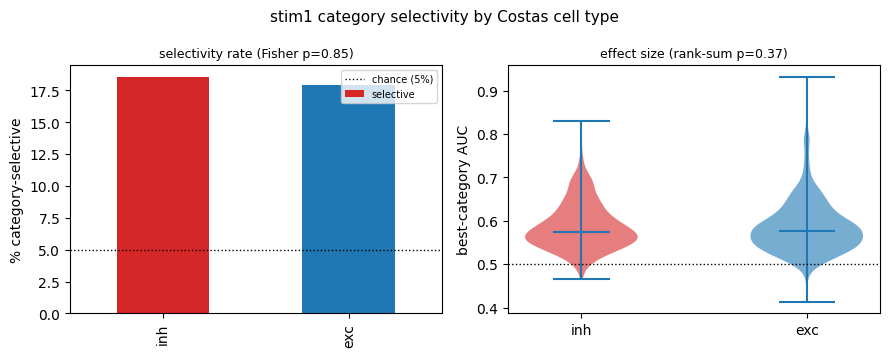

In [6]:
# [2.2] selectivity by Costas cell type: rate + threshold-free effect size (AUC)
from scipy.stats import fisher_exact, mannwhitneyu
tested = sel_df[sel_df.tested]
tab = pd.crosstab(tested.celltype, tested.selective)
print('cell type × selective:'); print(tab.to_string())
prop = tested.groupby('celltype').selective.mean().reindex(GROUPS)
print('\nfraction category-selective:')
print((prop * 100).round(1).astype(str).add(' %').to_string())
p_fish = np.nan
if set(GROUPS) <= set(tab.index) and {True, False} <= set(tab.columns):
    ct2 = tab.reindex(index=[GROUPS[1], GROUPS[0]], columns=[False, True]).fillna(0).values
    OR, p_fish = fisher_exact(ct2)       # proper 2x2 (reindex(...).values)
    print(f'\nFisher exact ({GROUPS[1]} vs {GROUPS[0]}): p={p_fish:.3g}, OR={OR:.2f}')

# threshold-free: compare the rate-invariant effect size (best-category AUC) between types
a = tested[tested.celltype == GROUPS[0]].best_auc.dropna()
b = tested[tested.celltype == GROUPS[1]].best_auc.dropna()
p_auc = mannwhitneyu(a, b).pvalue if len(a) and len(b) else np.nan
print(f'\nbest-category AUC (0.5=chance): {GROUPS[0]} median={a.median():.3f} (n={len(a)}) | '
      f'{GROUPS[1]} median={b.median():.3f} (n={len(b)})  rank-sum p={p_auc:.3g}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
(prop * 100).plot(kind='bar', color=[GRP_COL[g] for g in GROUPS], ax=axes[0])
axes[0].axhline(ALPHA * 100, color='k', ls=':', lw=1, label=f'chance ({ALPHA:.0%})')
axes[0].set_ylabel('% category-selective'); axes[0].set_xlabel('')
axes[0].set_title(f'selectivity rate (Fisher p={p_fish:.2g})', fontsize=9); axes[0].legend(fontsize=7)
parts = axes[1].violinplot([a, b], showmedians=True)
for pc, g in zip(parts['bodies'], GROUPS):
    pc.set_facecolor(GRP_COL[g]); pc.set_alpha(0.6)
axes[1].axhline(0.5, color='k', ls=':', lw=1)
axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(GROUPS)
axes[1].set_ylabel('best-category AUC'); axes[1].set_title(f'effect size (rank-sum p={p_auc:.2g})', fontsize=9)
fig.suptitle('stim1 category selectivity by Costas cell type', fontsize=11)
fig.tight_layout(); plt.show()

### [2.3] Rate-matched re-test

High-rate cells are easier to call selective (more spikes → more power). Costas `inh` cells tend to
fire faster, so match each `inh` cell to the nearest-firing-rate `exc` cell and re-compare — if the
difference survives, it isn't a firing-rate detectability artifact.

In [7]:
# [2.3] nearest-firing-rate matching (inh -> exc), then re-test on the matched set
def rate_match(df, g_small, g_pool, rate_col='resp_rate'):
    a = df[df.celltype == g_small]
    b = df[df.celltype == g_pool]
    if not len(a) or not len(b):
        return None, None
    br = np.log10(np.clip(b[rate_col].to_numpy(dtype=float), 1e-6, None))
    bidx = list(b.index); used = set(); pa, pb = [], []
    for i, row in a.iterrows():
        lr = np.log10(max(float(row[rate_col]), 1e-6))
        d = np.abs(br - lr).copy()
        for k, ix in enumerate(bidx):
            if ix in used:
                d[k] = np.inf
        k = int(np.argmin(d))
        if np.isfinite(d[k]):
            used.add(bidx[k]); pa.append(i); pb.append(bidx[k])
    return df.loc[pa], df.loc[pb]

A, B = rate_match(tested, GROUPS[0], GROUPS[1])
if A is None or len(A) < 5:
    print('not enough cells to rate-match')
else:
    print(f'matched {len(A)} pairs | median resp_rate: {GROUPS[0]}={A.resp_rate.median():.2f} Hz, '
          f'{GROUPS[1]}={B.resp_rate.median():.2f} Hz  (was '
          f'{tested[tested.celltype==GROUPS[0]].resp_rate.median():.2f} vs '
          f'{tested[tested.celltype==GROUPS[1]].resp_rate.median():.2f})')
    ct = np.array([[int((~B.selective).sum()), int(B.selective.sum())],
                   [int((~A.selective).sum()), int(A.selective.sum())]])   # rows: exc, inh
    ORm, pm = fisher_exact(ct)
    print(f'matched % selective: {GROUPS[0]} {A.selective.mean():.0%} vs '
          f'{GROUPS[1]} {B.selective.mean():.0%}   Fisher p={pm:.3g}, OR={ORm:.2f}')
    pa_auc = mannwhitneyu(A.best_auc.dropna(), B.best_auc.dropna()).pvalue
    print(f'matched best-category AUC: {GROUPS[0]} {A.best_auc.median():.3f} vs '
          f'{GROUPS[1]} {B.best_auc.median():.3f}   rank-sum p={pa_auc:.3g}')

matched 275 pairs | median resp_rate: inh=1.62 Hz, exc=1.62 Hz  (was 1.62 vs 1.35)
matched % selective: inh 19% vs exc 21%   Fisher p=0.521, OR=0.85
matched best-category AUC: inh 0.575 vs exc 0.586   rank-sum p=0.292


## Section 3 — Full-trial PSTHs, by Costas cell type

Whole trial — encoding pic1-3, delay (maintenance), probe — each panel split by whether the cell's
**selective category is present (in) or absent (out)**. FRs are **% change vs the −0.9 to −0.3 s
pre-pic1 baseline** (0 = baseline).

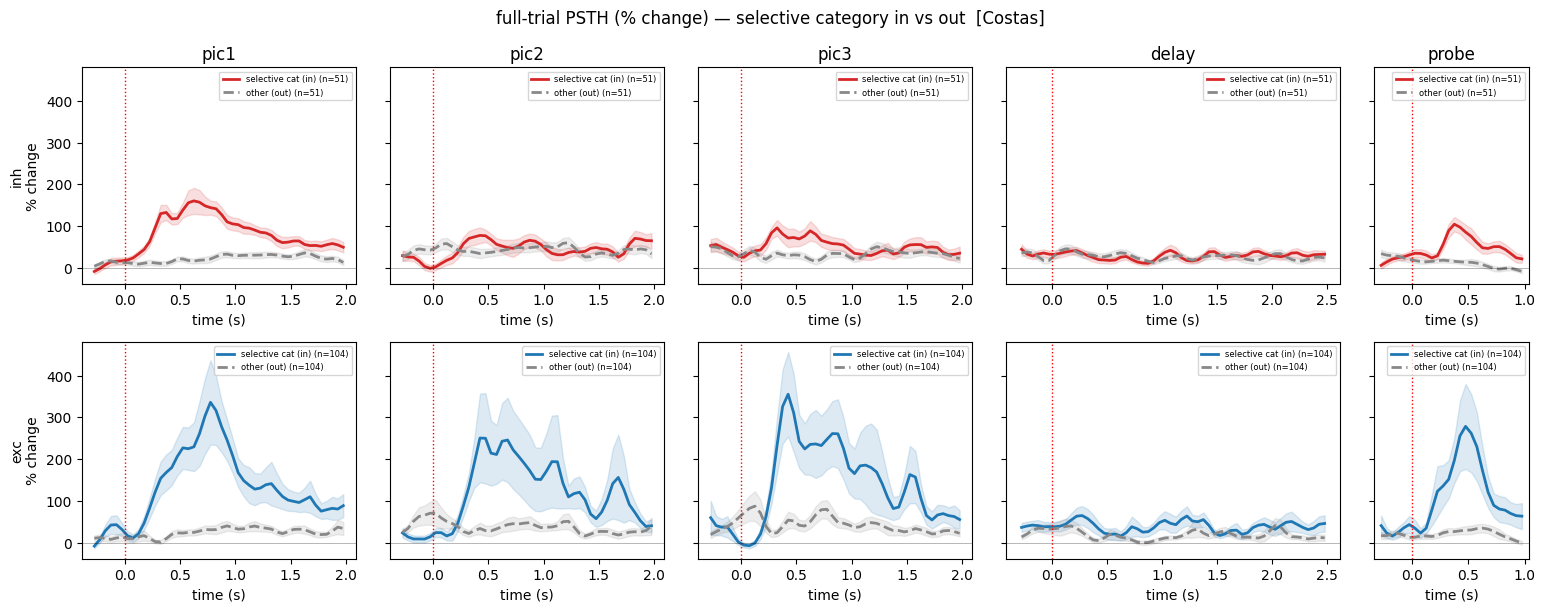

In [8]:
# [3.1] full-trial PSTH: selective category present (in) vs absent (out), per epoch, per cell type
EPOCHS = [('enc1', 'pic1', (-0.3, 2.0)), ('enc2', 'pic2', (-0.3, 2.0)),
          ('enc3', 'pic3', (-0.3, 2.0)), ('delay', 'delay', (-0.3, 2.5)),
          ('probe', 'probe', (-0.3, 1.0))]        # encoding pics shown ~2.0 s each
uid2idx = {u: i for i, u in enumerate(units_df.unit_id)}
sel_units = sel_df[sel_df.selective].copy()

def _epoch_traces(spk, tt, pref):
    """in/out PSTH per epoch for one cell, as % change from the pre-pic1 baseline."""
    e1 = tt.enc1_on.to_numpy(float); e1 = e1[np.isfinite(e1) & (e1 > 0)]
    if e1.size == 0:
        return None
    base = window_counts(spk, e1, *BASELINE).mean() / (BASELINE[1] - BASELINE[0])  # baseline Hz
    if base <= 0:
        return None
    res = {}
    for ep, _lab, win in EPOCHS:
        on, valid, inm = epoch_alignment(tt, ep, pref)
        d = {}
        for key, mask in (('in', inm), ('out', valid & ~inm)):
            oo = on[mask]
            if oo.size > 0:
                r, t = psth(spk, oo, window=win, bin_ms=BIN_MS, sigma_ms=SIGMA_MS)
                d[key] = ((r - base) / base * 100.0, t)
        res[ep] = d
    return res

fig, axes = plt.subplots(len(GROUPS), len(EPOCHS), figsize=(3.1 * len(EPOCHS), 3.1 * len(GROUPS)),
                         sharey=True, squeeze=False,
                         gridspec_kw=dict(width_ratios=[w[1] - w[0] for _, _, w in EPOCHS]))
for ri, g in enumerate(GROUPS):
    acc = {ep: {'in': [], 'out': [], 't': None} for ep, _, _ in EPOCHS}
    for _, row in sel_units[sel_units.celltype == g].iterrows():
        tr = _epoch_traces(spikes[uid2idx[row.unit_id]],
                           trial_table(trials_by_session.get(row.session_id)), row.pref_cat)
        if tr is None:
            continue
        for ep, _, _ in EPOCHS:
            for key in ('in', 'out'):
                if key in tr[ep]:
                    z, t = tr[ep][key]; acc[ep][key].append(z); acc[ep]['t'] = t
    for ci, (ep, lab, win) in enumerate(EPOCHS):
        ax = axes[ri][ci]; t = acc[ep]['t']
        for key, col, ls, name in (('in', GRP_COL[g], '-', 'selective cat (in)'),
                                   ('out', '#888', '--', 'other (out)')):
            A_ = acc[ep][key]
            if A_ and t is not None:
                A_ = np.array(A_); m = A_.mean(0); s = A_.std(0) / np.sqrt(len(A_))
                ax.plot(t, m, color=col, ls=ls, lw=2, label=f'{name} (n={len(A_)})')
                ax.fill_between(t, m - s, m + s, color=col, alpha=0.15)
        ax.axvline(0, color='r', ls=':', lw=1); ax.axhline(0, color='k', lw=0.5, alpha=0.4)
        if ri == 0:
            ax.set_title(lab)
        if ci == 0:
            ax.set_ylabel(f'{g}\n% change')
        ax.set_xlabel('time (s)'); ax.legend(fontsize=6, loc='upper right')
fig.suptitle('full-trial PSTH (% change) — selective category in vs out  [Costas]', fontsize=12)
fig.tight_layout(); plt.show()

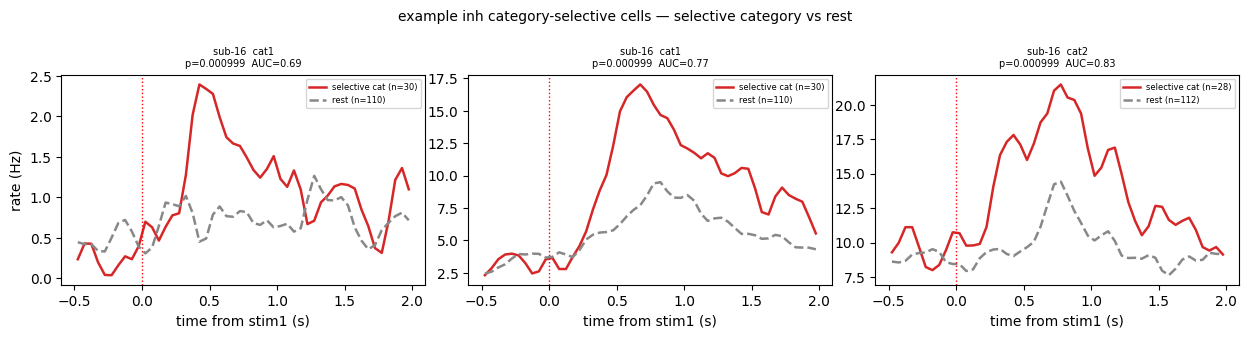

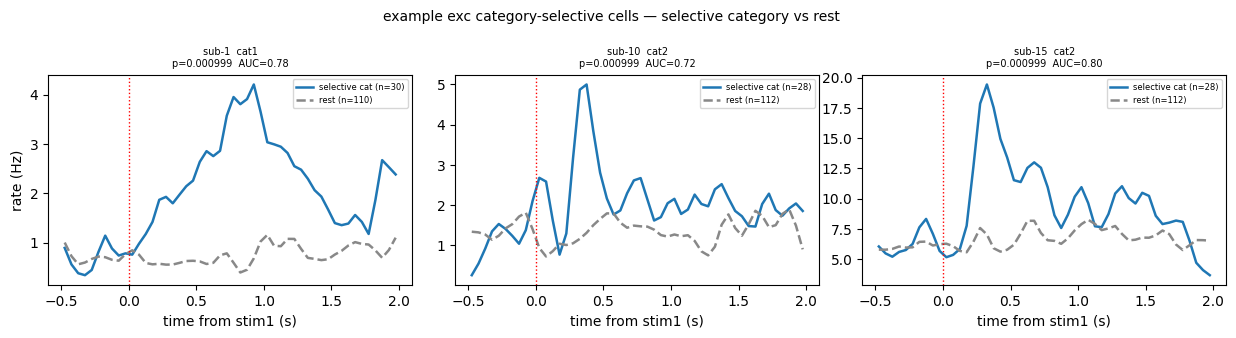

In [9]:
# [3.2] example single cells: selective category vs rest (stim1-aligned), most significant
N_EX = 3
for g in GROUPS:
    top = sel_units[sel_units.celltype == g].sort_values('p').head(N_EX)
    if not len(top):
        print(f'no selective {g} cells'); continue
    fig, axes = plt.subplots(1, len(top), figsize=(4.2 * len(top), 3.4), squeeze=False)
    for ax, (_, row) in zip(axes[0], top.iterrows()):
        j = uid2idx[row.unit_id]
        on, cat = trial_onsets_categories(trials_by_session.get(row.session_id), keep=CATS)
        for onset_set, name, col, ls in ((on[cat == row.pref_cat], 'selective cat', GRP_COL[g], '-'),
                                         (on[cat != row.pref_cat], 'rest', '#888', '--')):
            if onset_set.size:
                r, t = psth(spikes[j], onset_set, window=PSTH_WIN, bin_ms=BIN_MS, sigma_ms=SIGMA_MS)
                ax.plot(t, r, color=col, ls=ls, lw=1.8, label=f'{name} (n={onset_set.size})')
        ax.axvline(0, color='r', ls=':', lw=1)
        ax.set_title(f"{row.unit_id.split('_ses')[0]}  cat{int(row.pref_cat)}\n"
                     f"p={row.p:.3g}  AUC={row.best_auc:.2f}", fontsize=7)
        ax.set_xlabel('time from stim1 (s)'); ax.legend(fontsize=6)
    axes[0][0].set_ylabel('rate (Hz)')
    fig.suptitle(f'example {g} category-selective cells — selective category vs rest', fontsize=10)
    fig.tight_layout(); plt.show()

## Section 3B — Load-1 delay only (single held item)

In **load-1** trials only one item is held through the delay (no interference). Split load-1 trials
by whether that single held item **is the cell's selective category (in)** or **another (out)**.

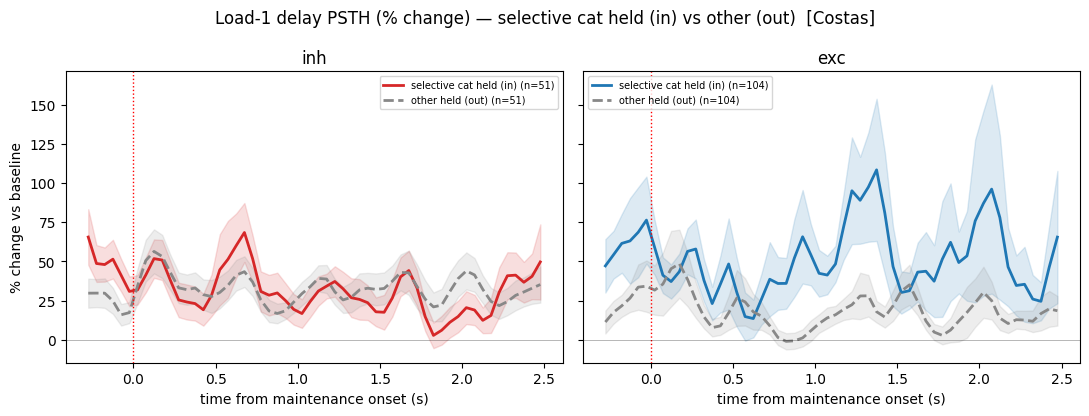

In [10]:
# [3B.1] delay-period PSTH restricted to LOAD-1 trials, selective cat held (in) vs other (out)
DELAY_WIN = (-0.3, 2.5)
fig, axes = plt.subplots(1, len(GROUPS), figsize=(5.5 * len(GROUPS), 4.2), sharey=True, squeeze=False)
for ax, g in zip(axes[0], GROUPS):
    acc = {'in': [], 'out': []}; tt_t = None
    for _, row in sel_units[sel_units.celltype == g].iterrows():
        spk = spikes[uid2idx[row.unit_id]]
        T = trial_table(trials_by_session.get(row.session_id))
        e1 = T.enc1_on.to_numpy(float); e1 = e1[np.isfinite(e1) & (e1 > 0)]
        if e1.size == 0:
            continue
        base = window_counts(spk, e1, *BASELINE).mean() / (BASELINE[1] - BASELINE[0])
        if base <= 0:
            continue
        on, valid, inm = epoch_alignment(T, 'delay', row.pref_cat)
        load1 = (T.loads.to_numpy(float) == 1)
        for key, mask in (('in', inm & load1), ('out', valid & ~inm & load1)):
            oo = on[mask]
            if oo.size > 0:
                r, t = psth(spk, oo, window=DELAY_WIN, bin_ms=BIN_MS, sigma_ms=SIGMA_MS)
                acc[key].append((r - base) / base * 100.0); tt_t = t
    for key, col, ls, name in (('in', GRP_COL[g], '-', 'selective cat held (in)'),
                               ('out', '#888', '--', 'other held (out)')):
        A_ = acc[key]
        if A_ and tt_t is not None:
            A_ = np.array(A_); m = A_.mean(0); s = A_.std(0) / np.sqrt(len(A_))
            ax.plot(tt_t, m, color=col, ls=ls, lw=2, label=f'{name} (n={len(A_)})')
            ax.fill_between(tt_t, m - s, m + s, color=col, alpha=0.15)
    ax.axvline(0, color='r', ls=':', lw=1); ax.axhline(0, color='k', lw=0.5, alpha=0.4)
    ax.set_title(g); ax.set_xlabel('time from maintenance onset (s)'); ax.legend(fontsize=7)
axes[0][0].set_ylabel('% change vs baseline')
fig.suptitle('Load-1 delay PSTH (% change) — selective cat held (in) vs other (out)  [Costas]', fontsize=12)
fig.tight_layout(); plt.show()

--- inh (n=51 cells) ---
  selective cat delay:  +25.9%  (vs 0: p=3.16e-05)
  other:                +16.7%  (vs 0: p=4.93e-05)
  selective vs other (paired): p=0.903

--- exc (n=104 cells) ---
  selective cat delay:  +13.2%  (vs 0: p=0.000142)
  other:                 +6.2%  (vs 0: p=0.0172)
  selective vs other (paired): p=0.000952



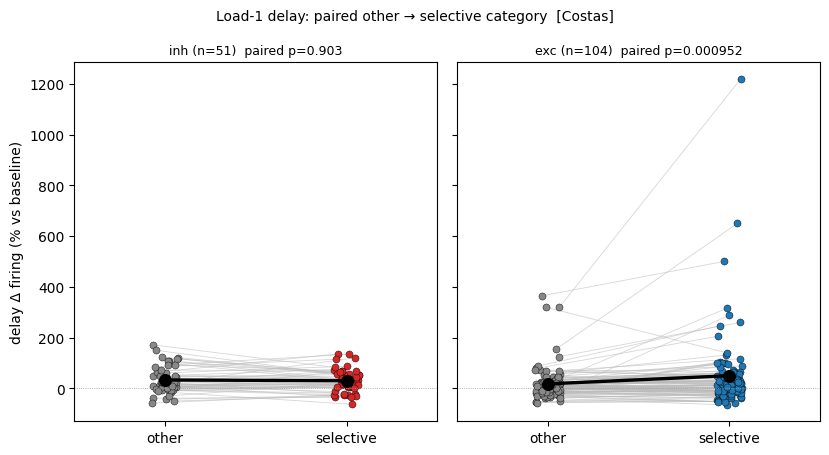

In [11]:
# [3B.2] load-1 delay stats: % change vs baseline, selective-cat vs other, per cell type
from scipy.stats import wilcoxon

def _delay_pct(spk, T, pref):
    e1 = T.enc1_on.to_numpy(float); e1 = e1[np.isfinite(e1) & (e1 > 0)]
    if e1.size == 0:
        return np.nan, np.nan
    base = window_counts(spk, e1, *BASELINE).mean() / (BASELINE[1] - BASELINE[0])
    if base <= 0:
        return np.nan, np.nan
    on, valid, inm = epoch_alignment(T, 'delay', pref)
    load1 = (T.loads.to_numpy(float) == 1)
    def pct(mask):
        oo = on[mask]
        if oo.size == 0:
            return np.nan
        rr = window_counts(spk, oo, *DELAY_STAT).mean() / (DELAY_STAT[1] - DELAY_STAT[0])
        return (rr - base) / base * 100.0
    return pct(inm & load1), pct(valid & ~inm & load1)

rows = []
for _, row in sel_units.iterrows():
    pr, npr = _delay_pct(spikes[uid2idx[row.unit_id]],
                         trial_table(trials_by_session.get(row.session_id)), row.pref_cat)
    rows.append((row.unit_id, row.celltype, pr, npr))
pc = pd.DataFrame(rows, columns=['unit_id', 'celltype', 'pref_pct', 'nonpref_pct'])

summary = []
for g in GROUPS:
    sub = pc[pc.celltype == g].dropna(subset=['pref_pct', 'nonpref_pct'])
    if len(sub) < 5:
        print(f'{g}: too few cells with both conditions (n={len(sub)}) — skipping stats'); continue
    p_pref = wilcoxon(sub.pref_pct)[1]; p_non = wilcoxon(sub.nonpref_pct)[1]
    p_diff = wilcoxon(sub.pref_pct, sub.nonpref_pct)[1]
    print(f'--- {g} (n={len(sub)} cells) ---')
    print(f'  selective cat delay: {sub.pref_pct.median():+6.1f}%  (vs 0: p={p_pref:.3g})')
    print(f'  other:               {sub.nonpref_pct.median():+6.1f}%  (vs 0: p={p_non:.3g})')
    print(f'  selective vs other (paired): p={p_diff:.3g}\n')
    summary.append((g, sub))

if summary:
    fig, axes = plt.subplots(1, len(summary), figsize=(4.2 * len(summary), 4.6),
                             squeeze=False, sharey=True)
    rng = np.random.default_rng(0)
    for ax, (g, sub) in zip(axes[0], summary):
        npref = sub.nonpref_pct.to_numpy(); pref = sub.pref_pct.to_numpy()
        jit = rng.uniform(-0.07, 0.07, len(sub))
        x0, x1 = 1 + jit, 2 + jit
        for a_, b_, xa, xb in zip(npref, pref, x0, x1):
            ax.plot([xa, xb], [a_, b_], color='#bbb', lw=0.6, alpha=0.6, zorder=1)
        ax.scatter(x0, npref, s=26, color='#888', edgecolor='k', linewidth=0.3, zorder=2)
        ax.scatter(x1, pref, s=26, color=GRP_COL[g], edgecolor='k', linewidth=0.3, zorder=2)
        m0, m1 = np.nanmean(npref), np.nanmean(pref)
        ax.plot([1, 2], [m0, m1], color='k', lw=2.4, zorder=3)
        ax.scatter([1, 2], [m0, m1], s=70, color='k', zorder=4)
        ax.axhline(0, color='#999', lw=0.6, ls=':')
        p_diff = wilcoxon(pref, npref)[1]
        ax.set_xticks([1, 2]); ax.set_xticklabels(['other', 'selective']); ax.set_xlim(0.5, 2.5)
        ax.set_title(f'{g} (n={len(sub)})  paired p={p_diff:.3g}', fontsize=9)
    axes[0][0].set_ylabel('delay Δ firing (% vs baseline)')
    fig.suptitle('Load-1 delay: paired other → selective category  [Costas]', fontsize=10)
    fig.tight_layout(); plt.show()

## Section 4 — Save the selective-cell table

In [12]:
# [4.1] save per-unit selectivity + provenance
region_tag = '+'.join(a.lower() for a in SELECT_AREAS)
out = CELLTYPE_DIR / f'stim1_selectivity_{region_tag}.csv'
out.parent.mkdir(parents=True, exist_ok=True)
sel_df.to_csv(out, index=False)
prov = dict(dataset=DATASET, areas=SELECT_AREAS, celltype_scheme=CELLTYPE_COL,
            method='one-vs-rest max-statistic permutation (no FDR; selection built into the null)',
            resp_win=list(RESP_WIN), n_perm=N_PERM, alpha=ALPHA, min_trials=MIN_TRIALS,
            n_units=int(len(sel_df)), n_tested=n_tested, n_selective=int(sel_df.selective.sum()),
            selective_by_type={k: int(v) for k, v in
                               sel_df[sel_df.selective].celltype.value_counts().items()})
out.with_suffix('.json').write_text(json.dumps(prov, indent=2, default=float))
print(f'wrote {out}  ({int(sel_df.selective.sum())} selective / {n_tested} tested)')
sel_df.head(12)

wrote E:\SBCAT\celltyping\outputs\celltype\stim1_selectivity_hippocampus+amygdala.csv  (155 selective / 856 tested)


,unit_id,session_id,subject,location,celltype,p,selective,pref_cat,best_effect,best_auc,resp_rate,n_cat,tested
0,sub-1_ses-1_ecephys+image_u022,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.292707,False,4,0.613839,0.588648,1.607143,5,True
1,sub-1_ses-1_ecephys+image_u023,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.861139,False,4,0.111607,0.531409,0.223214,5,True
2,sub-1_ses-1_ecephys+image_u024,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.612388,False,1,0.886364,0.536667,6.803571,5,True
3,sub-1_ses-1_ecephys+image_u025,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.245754,False,5,0.564569,0.588659,1.303571,5,True
4,sub-1_ses-1_ecephys+image_u026,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.055944,False,5,0.796870,0.607670,1.116071,5,True
5,sub-1_ses-1_ecephys+image_u027,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.134865,False,5,0.841937,0.545231,0.848214,5,True
6,sub-1_ses-1_ecephys+image_u028,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.205794,False,1,0.428030,0.593788,0.705357,5,True
7,sub-1_ses-1_ecephys+image_u029,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.807193,False,4,0.334821,0.544802,2.276786,5,True
8,sub-1_ses-1_ecephys+image_u030,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.230769,False,3,2.441003,0.627335,14.696429,5,True
9,sub-1_ses-1_ecephys+image_u031,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,exc,0.174825,False,5,0.707555,0.593904,1.419643,5,True


## Reading the result

- **`[2.1]`** — selective rate vs the 5% chance floor tells you there's real signal at all.
- **`[2.2]`** — two views of "do Costas inh vs exc differ": the **selectivity rate** (Fisher) and the
  threshold-free **best-category AUC** (rank-sum). AUC is rate-invariant, so it's the more honest
  comparison.
- **`[2.3]`** — the **rate-matched** re-test. If a difference in `[2.2]` disappears here, it was a
  firing-rate detectability artifact, not cell-type biology.
- **`[3.1]` / `[3B.2]`** — whether selective cells hold their category through the **delay**
  (sustained in > out), per cell type.
- Filter: one-vs-rest max-statistic permutation — the best-category selection is inside the null,
  so there's no double-dipping and no need to correct for the 5 categories. No FDR: the inh/exc
  comparison shares a 5% false-positive floor, so it cancels.